# Check linearity of the CDR tracer

In [1]:
import xarray as xr

In [2]:
import matplotlib.pyplot as plt

In [3]:
outputs = {
    "dor": {"exp": "exp0", "ctrl_subdir": "OUTPUT_dor"},
    "oae": {"exp": "exp0", "ctrl_subdir": "OUTPUT_oae"},
}

In [4]:
for key in outputs:
    ds = xr.open_mfdataset(
        f"roms/{outputs[key]['exp']}/{outputs[key]['ctrl_subdir']}/INTEGRATED/integrated.*.nc",
        combine="nested",
        concat_dim="time",
    )
    if "abs_time" in ds:
        ds = ds.rename({"abs_time": "time"})

    outputs[key]["ds"] = ds

/tmp/ipykernel_1545213/2941304232.py:8: UserWarning: rename 'abs_time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"abs_time": "time"})


In [5]:
colors = {
    "JP10": "#d4b9da", "JP7": "#df65b0", "JP8": "#980043",
    "VI10": "#A8E6A3", "VI7": "#4CAF50", "VI8": "#1B5E20",
    "BC10": "#A7C7E7", "BC7": "#2196F3", "BC8": "#0D47A1",
    "EC10": "#FFD580", "EC7": "#FFA500", "EC8": "#CC5500",
}

base_labels = {
    "JP10": r"\mathrm{J10}", "JP7": r"\mathrm{J100}", "JP8": r"\mathrm{J1000}",
    "VI10": r"\mathrm{V10}", "VI7": r"\mathrm{V100}", "VI8": r"\mathrm{V1000}",
    "BC10": r"\mathrm{B10}", "BC7": r"\mathrm{B100}", "BC8": r"\mathrm{B1000}",
    "EC10": r"\mathrm{E10}", "EC7": r"\mathrm{E100}", "EC8": r"\mathrm{E1000}",
}

scenarios = {
    "dor": {"title": "DOR", "sign": r"\ominus"},
    "oae": {"title": "OAE", "sign": r"\oplus"},
}

exp_pref_list = ["JP", "VI", "BC", "EC"]
amps = ("10", "7", "8")

for scen in scenarios.values():
    scen["exps"] = {
        exp: {"color": colors[exp], "label": rf"{base_labels[exp]}\!{scen['sign']}"}
        for exp in colors
    }

In [6]:
BACKGROUND_COLOR = "#f5f5f5"

In [7]:
def eta_deficit(ds_ctrl, exp, scenario_key):
    conserved = ds_ctrl[f"{exp}_conserved"].where(ds_ctrl[f"{exp}_conserved"] != 0)
    if scenario_key == "dor":
        return 1 - ds_ctrl[f"{exp}_deficit"] / conserved
    else:
        return ds_ctrl[f"{exp}_oae_def"] / conserved


def plot_efficiency_curves(ax, ds_ctrl, scenario_key, enum="(a)"):
    exps = scenarios[scenario_key]["exps"]
    for exp_pref in exp_pref_list:
        for amp in amps:
            exp = f"{exp_pref}{amp}"
            eta = eta_deficit(ds_ctrl, exp, scenario_key)
            label = exps[exp]["label"]
            ax.plot(
                ds_ctrl.time, eta, color=exps[exp]["color"],
                label=rf"$\tilde{{\mathcal{{E}}}}_{{{label}}}$",
                linewidth=2,
            )

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    ax.set_title(rf"{enum} {scenarios[scenario_key]['title']} uptake efficiencies")
    ax.grid()
    ax.patch.set_facecolor(BACKGROUND_COLOR)
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.2),
        ncol=len(exp_pref_list), facecolor=BACKGROUND_COLOR, fontsize=12,
    )

In [8]:
def plot_efficiency_curves_diff(ax, ds_ctrl, scenario_key, enum="(b)", relative=False):
    exps = scenarios[scenario_key]["exps"]
    ref_amp, amps_to_plot = amps[0], amps[1:]

    for exp_pref in exp_pref_list:
        exp_ref = f"{exp_pref}{ref_amp}"
        eta_ref = eta_deficit(ds_ctrl, exp_ref, scenario_key)
        ref_label = exps[exp_ref]["label"]

        for amp in amps_to_plot:
            exp = f"{exp_pref}{amp}"
            eta = eta_deficit(ds_ctrl, exp, scenario_key)

            n = min(eta_ref.sizes["time"], eta.sizes["time"])
            eta_ref_n = eta_ref.isel(time=slice(0, n))
            eta_n = eta.isel(time=slice(0, n))
            diff = eta_n - eta_ref_n
            if relative:
                diff = 100 * diff / eta_ref_n.where(eta_ref_n != 0)

            label = exps[exp]["label"]
            if relative:
                plot_label = rf"$(\tilde{{\mathcal{{E}}}}_{{{label}}}-\tilde{{\mathcal{{E}}}}_{{{ref_label}}})/\tilde{{\mathcal{{E}}}}_{{{ref_label}}}$"
            else:
                plot_label = rf"$\tilde{{\mathcal{{E}}}}_{{{label}}}-\tilde{{\mathcal{{E}}}}_{{{ref_label}}}$"

            ax.plot(
                ds_ctrl.time.isel(time=slice(0, n)), diff,
                color=exps[exp]["color"], label=plot_label, linewidth=2,
            )

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    title_prefix = scenarios[scenario_key]["title"]
    if relative:
        ax.set_ylabel("%")
        ax.set_title(rf"{enum} Relative difference in {title_prefix} uptake efficiencies")
    else:
        ax.set_title(rf"{enum} Absolute difference in {title_prefix} uptake efficiencies")
    ax.grid()
    ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
    ax.patch.set_facecolor(BACKGROUND_COLOR)
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.2),
        ncol=max(1, len(exp_pref_list) // 2), facecolor=BACKGROUND_COLOR, fontsize=12,
    )

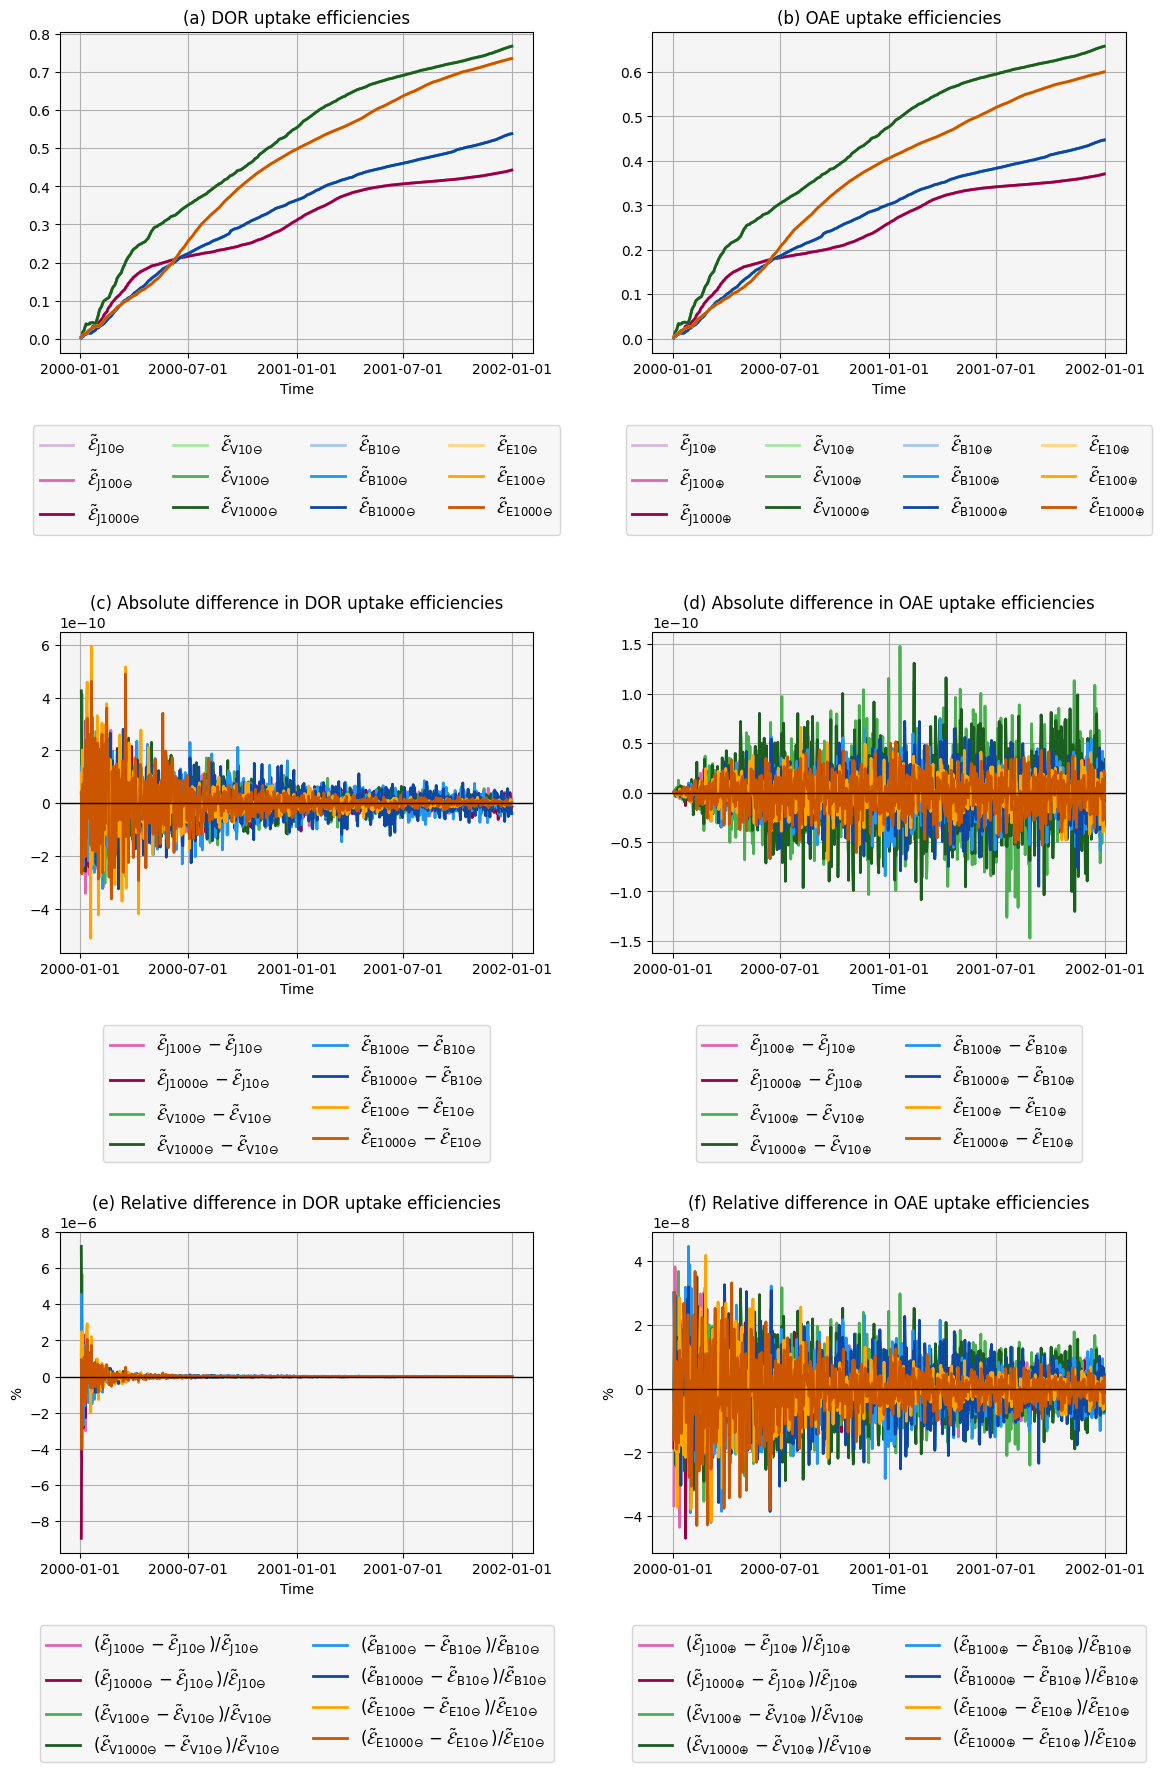

In [10]:
enum_list = [["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"]]

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
for j, key in enumerate(["dor", "oae"]):
    ds_ctrl = outputs[key]["ds"]
    plot_efficiency_curves(axs[0, j], ds_ctrl, key, enum=enum_list[0][j])
    plot_efficiency_curves_diff(axs[1, j], ds_ctrl, key, enum=enum_list[1][j], relative=False)
    plot_efficiency_curves_diff(axs[2, j], ds_ctrl, key, enum=enum_list[2][j], relative=True)
plt.tight_layout()

In [11]:
fig.savefig(
    "figures/linearity_cdr_tracer.png",
    dpi=300,
    bbox_inches="tight",
)